# Week 2 — AMS-02 Multi-Subsystem PID

This notebook builds a **simulated AMS-02** pipeline:

- `AMS02Simulator` orchestrates detector subsystems
- Subsystem classes: `TrackerModel`, `TOFModel`, `RICHModel`, `TRDModel`, `ECALModel`
- `DatasetBuilder` generates a tabular dataset
- `PIDTrainer` trains a baseline classifier

Species covered: `e-`, `e+`, `p`, `He`, `C`, `O`, `Si`, `Fe`

In [1]:
# --- Setup ---
import math
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
print('OK')


OK


## 1) Species and kinematics

We use the relations:

- Rigidity: **$R = p/Z$** (in GV)
- Approximate momentum: **$p ≈ |Z|·R$** (GeV/c)
- **$β = p / \sqrt(p² + m²)$**

Nuclear mass is approximated as **$A·m_p$**.


In [2]:
@dataclass(frozen=True)
class Species:
    label: str
    Z: int
    A: int
    charge_sign: int  # -1 or +1
    is_lepton: bool


class Kinematics:
    """Kinematics helper."""
    m_p_GeV = 0.9382720813
    m_e_GeV = 0.00051099895

    @classmethod
    def mass_GeV(cls, s: Species) -> float:
        return cls.m_e_GeV if s.is_lepton else s.A * cls.m_p_GeV

    @classmethod
    def beta_from_rigidity(cls, R_GV: float, s: Species) -> float:
        p = abs(s.Z) * R_GV
        m = cls.mass_GeV(s)
        return float(p / math.sqrt(p*p + m*m))


SPECIES: List[Species] = [
    Species('e-', 1, 0, -1, True),
    Species('e+', 1, 0, +1, True),
    Species('p',  1, 1, +1, False),
    Species('He', 2, 4, +1, False),
    Species('C',  6, 12, +1, False),
    Species('O',  8, 16, +1, False),
    Species('Si', 14, 28, +1, False),
    Species('Fe', 26, 56, +1, False),
]
SPECIES_BY_LABEL = {s.label: s for s in SPECIES}

for lab in ['e-', 'p', 'He', 'Fe']:
    s = SPECIES_BY_LABEL[lab]
    print(lab, 'beta at R=10 GV:', Kinematics.beta_from_rigidity(10.0, s))


e- beta at R=10 GV: 0.9999999986944005
p beta at R=10 GV: 0.9956270793209386
He beta at R=10 GV: 0.9828446860913361
Fe beta at R=10 GV: 0.9801848579964545


## 2) Base utilities


In [3]:
class RNG:
    def __init__(self, rng: Optional[np.random.Generator] = None):
        self.rng = rng if rng is not None else np.random.default_rng()

    def smear_gauss(self, x: float, sigma: float) -> float:
        return float(x + self.rng.normal(0.0, sigma))

    @staticmethod
    def clamp01(x: float) -> float:
        return float(min(1.0, max(0.0, x)))


## 3) Subsystem models

Each subsystem returns a dictionary of observable(s).


## 3A) Week 1 tracker integration
These helpers are copied from the Week 1 tracker notebooks so the Week 2 PID model can use a tracker response calibrated from simulated silicon hits, circle fits, and an empirical rigidity-resolution curve.

In [4]:

# --- Week 1 tracker integration helpers ---
GEV_C2_TO_KG = 1.78266192e-27
E_CHARGE = 1.602176634e-19
C_LIGHT = 3.0e8
B0 = np.array([0.0, 0.0, 0.15])
Z_LAYERS = np.linspace(0.1, 0.9, 7)


def rigidity_to_relativistic_w1(Z_abs: int, mass_GeV: float, R_GV: float):
    p_GeV = abs(Z_abs) * R_GV
    E_GeV = np.sqrt(p_GeV**2 + mass_GeV**2)
    gamma = E_GeV / mass_GeV
    beta = np.sqrt(1.0 - 1.0 / gamma**2)
    return float(beta), float(gamma), float(p_GeV)


def velocity_from_speed_and_pitch_w1(v_mag, pitch_angle_deg, B_vec):
    B = np.array(B_vec, dtype=float)
    B_hat = B / np.linalg.norm(B)
    theta = np.deg2rad(pitch_angle_deg)
    v_par_mag = v_mag * np.cos(theta)
    v_perp_mag = v_mag * np.sin(theta)

    if np.allclose(B_hat, [0, 0, 1]) or np.allclose(B_hat, [0, 0, -1]):
        e1 = np.array([1.0, 0.0, 0.0])
    else:
        e1 = np.array([0.0, 0.0, 1.0])
        if np.isclose(np.abs(np.dot(e1, B_hat)), 1.0):
            e1 = np.array([0.0, 1.0, 0.0])

    v_perp_dir = np.cross(B_hat, e1)
    v_perp_dir /= np.linalg.norm(v_perp_dir)
    v_par = v_par_mag * B_hat
    v_perp = v_perp_mag * v_perp_dir
    return v_par + v_perp


def boris_push_w1(r0, v0, q, m_eff, B_vec, dt, n_steps):
    r = np.zeros((n_steps + 1, 3))
    v = np.zeros((n_steps + 1, 3))
    t_arr = np.linspace(0, n_steps * dt, n_steps + 1)
    r[0] = np.array(r0, dtype=float)
    v[0] = np.array(v0, dtype=float)

    B = np.array(B_vec, dtype=float)
    qmdt2 = (q / m_eff) * dt / 2.0
    t_vec = qmdt2 * B
    t_mag2 = np.dot(t_vec, t_vec)
    s_vec = 2.0 * t_vec / (1.0 + t_mag2)

    for n in range(n_steps):
        v_minus = v[n]
        v_prime = v_minus + np.cross(v_minus, t_vec)
        v_plus = v_minus + np.cross(v_prime, s_vec)
        v[n + 1] = v_plus
        r[n + 1] = r[n] + v[n + 1] * dt

    return t_arr, r, v


def simulate_relativistic_track_w1(Z_signed, mass_GeV, mass_kg, R_GV=10.0, pitch_angle_deg=60.0,
                                   B_vec=B0, n_periods=2.0, steps_per_period=220):
    beta, gamma, _ = rigidity_to_relativistic_w1(abs(Z_signed), mass_GeV, R_GV)
    v_mag = beta * C_LIGHT
    v0 = velocity_from_speed_and_pitch_w1(v_mag, pitch_angle_deg, B_vec)
    r0 = np.array([0.0, 0.0, 0.0])
    q = Z_signed * E_CHARGE
    B_mag = np.linalg.norm(B_vec)
    omega_c = np.abs(q) * B_mag / (gamma * mass_kg)
    T_c = 2 * np.pi / omega_c
    dt = T_c / steps_per_period
    n_steps = int(n_periods * steps_per_period)
    return *boris_push_w1(r0, v0, q, gamma * mass_kg, B_vec, dt, n_steps), gamma


def intersect_track_with_layers_w1(t, r, z_layers=Z_LAYERS, direction="forward"):
    z = r[:, 2]
    hits = []
    for i_layer, zL in enumerate(z_layers):
        for i in range(len(z) - 1):
            z1, z2 = z[i], z[i + 1]
            if (z1 - zL) * (z2 - zL) <= 0 and (z2 != z1):
                if direction == "forward" and (z2 - z1) <= 0:
                    continue
                alpha = (zL - z1) / (z2 - z1)
                x1, y1, _ = r[i]
                x2, y2, _ = r[i + 1]
                hits.append({
                    'layer_index': i_layer,
                    'z_layer': zL,
                    'x': x1 + alpha * (x2 - x1),
                    'y': y1 + alpha * (y2 - y1),
                    'z': zL,
                    't': t[i] + alpha * (t[i + 1] - t[i]),
                })
                break
    return hits


def add_hit_noise_w1(hits, sigma_xy=50e-6, rng=None):
    rng = rng if rng is not None else np.random.default_rng()
    noisy_hits = []
    for h in hits:
        h2 = h.copy()
        h2['x_meas'] = h['x'] + rng.normal(0.0, sigma_xy)
        h2['y_meas'] = h['y'] + rng.normal(0.0, sigma_xy)
        noisy_hits.append(h2)
    return noisy_hits


def fit_circle_least_squares_w1(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    A = np.column_stack([2*x, 2*y, np.ones_like(x)])
    b = x**2 + y**2
    params, *_ = np.linalg.lstsq(A, b, rcond=None)
    xc, yc, cpar = params
    R_fit = np.sqrt(cpar + xc**2 + yc**2)
    return float(xc), float(yc), float(R_fit)


def theoretical_radius_w1(R_GV, pitch_angle_deg, Z_signed, B_vec=B0):
    theta = np.deg2rad(pitch_angle_deg)
    p_perp_SI = (abs(Z_signed) * R_GV * np.sin(theta)) * 1e9 * E_CHARGE / C_LIGHT
    B_mag = np.linalg.norm(B_vec)
    return float(p_perp_SI / (abs(Z_signed) * E_CHARGE * B_mag))


def estimate_rigidity_from_hits_w1(hits, R_true, pitch_angle_deg, Z_signed, B_vec=B0):
    x = np.array([h['x_meas'] for h in hits])
    y = np.array([h['y_meas'] for h in hits])
    _, _, R_fit_circle = fit_circle_least_squares_w1(x, y)
    R_theory_circle = theoretical_radius_w1(R_true, pitch_angle_deg, Z_signed, B_vec=B_vec)
    return float(R_true * (R_fit_circle / R_theory_circle)), float(R_fit_circle), float(R_theory_circle)


class Week1TrackerCalibration:
    def __init__(self, rng=None, B_vec=B0, sigma_xy=50e-6, z_layers=Z_LAYERS,
                 pitch_range=(30.0, 80.0), n_periods=2.0, steps_per_period=220):
        self.rng = rng if rng is not None else np.random.default_rng(123) #reproducible seed
        self.B_vec = np.array(B_vec, dtype=float)
        self.sigma_xy = sigma_xy
        self.z_layers = np.array(z_layers, dtype=float)
        self.pitch_range = pitch_range
        self.n_periods = n_periods
        self.steps_per_period = steps_per_period
        self.R_grid = None
        self.sigma_rel_grid = None

    def simulate_one_measurement(self, s: Species, R_true: float, pitch_deg: float):
        mass_GeV = Kinematics.mass_GeV(s)
        mass_kg = mass_GeV * GEV_C2_TO_KG
        Z_signed = int(s.charge_sign * abs(s.Z))
        t, r, v, gamma = simulate_relativistic_track_w1(
            Z_signed=Z_signed,
            mass_GeV=mass_GeV,
            mass_kg=mass_kg,
            R_GV=R_true,
            pitch_angle_deg=pitch_deg,
            B_vec=self.B_vec,
            n_periods=self.n_periods,
            steps_per_period=self.steps_per_period,
        )
        hits = intersect_track_with_layers_w1(t, r, z_layers=self.z_layers)
        if len(hits) < 3:
            return None
        noisy_hits = add_hit_noise_w1(hits, sigma_xy=self.sigma_xy, rng=self.rng)
        R_meas, R_fit_circle, R_theory_circle = estimate_rigidity_from_hits_w1(
            noisy_hits, R_true=R_true, pitch_angle_deg=pitch_deg, Z_signed=Z_signed, B_vec=self.B_vec
        )
        return {
            'R_meas': float(R_meas),
            'R_fit_circle': float(R_fit_circle),
            'R_theory_circle': float(R_theory_circle),
            'n_hits': int(len(noisy_hits)),
        }

    def fit_from_week1_sim(self, species: Species, R_grid=None, n_per_bin: int = 25):
        if R_grid is None:
            R_grid = np.geomspace(1.0, 300.0, 12)
        sigma_rel = []
        for R_true in R_grid:
            rel_errs = []
            for _ in range(n_per_bin):
                pitch_deg = float(self.rng.uniform(*self.pitch_range))
                out = self.simulate_one_measurement(species, float(R_true), pitch_deg)
                if out is None:
                    continue
                rel_errs.append((out['R_meas'] - R_true) / R_true)
            if len(rel_errs) == 0:
                sigma_rel.append(np.nan)
            else:
                abs_rel = np.abs(np.asarray(rel_errs, dtype=float))
                robust68 = float(np.quantile(abs_rel, 0.68))
                sigma_rel.append(float(np.clip(robust68, 0.015, 0.30)))
        self.R_grid = np.asarray(R_grid, dtype=float)
        self.sigma_rel_grid = np.asarray(sigma_rel, dtype=float)
        mask = np.isfinite(self.sigma_rel_grid)
        self.R_grid = self.R_grid[mask]
        self.sigma_rel_grid = self.sigma_rel_grid[mask]
        return pd.DataFrame({'R_GV': self.R_grid, 'sigma_rel': self.sigma_rel_grid})

    def sigma_rel(self, R_GV: float) -> float:
        if self.R_grid is None or self.sigma_rel_grid is None:
            proton_like = SPECIES_BY_LABEL['p']
            self.fit_from_week1_sim(proton_like)
        return float(np.interp(R_GV, self.R_grid, self.sigma_rel_grid,
                               left=self.sigma_rel_grid[0], right=self.sigma_rel_grid[-1]))

    def sigma_abs(self, R_GV: float) -> float:
        return float(max(5e-4, self.sigma_rel(R_GV) * R_GV))


In [5]:

class TrackerModel(RNG):
    """Tracker response calibrated from the Week 1 silicon-tracker simulation."""

    def __init__(self, rng: Optional[np.random.Generator] = None,
                 calibration: Optional[Week1TrackerCalibration] = None,
                 use_full_tracker_sim: bool = False):
        super().__init__(rng)
        self.calibration = calibration if calibration is not None else Week1TrackerCalibration(self.rng)
        self.use_full_tracker_sim = use_full_tracker_sim
        if self.calibration.R_grid is None:
            self.calibration.fit_from_week1_sim(SPECIES_BY_LABEL['p'], n_per_bin=20)

    def sigma_R(self, R_GV: float) -> float:
        return self.calibration.sigma_abs(R_GV)

    def measure(self, s: Species, R_true: float) -> Dict[str, float]:
        pitch_deg = float(self.rng.uniform(*self.calibration.pitch_range))

        if self.use_full_tracker_sim:
            tracker_out = self.calibration.simulate_one_measurement(s, R_true, pitch_deg)
            if tracker_out is None:
                R_meas = max(0.05, self.smear_gauss(R_true, self.sigma_R(R_true)))
                n_hits = 0
                tracker_mode = 'fallback_smear'
            else:
                R_meas = max(0.05, tracker_out['R_meas'])
                n_hits = tracker_out['n_hits']
                tracker_mode = 'week1_fullsim'
        else:
            R_meas = max(0.05, self.smear_gauss(R_true, self.sigma_R(R_true)))
            n_hits = len(self.calibration.z_layers)
            tracker_mode = 'week1_calibrated_smear'

        sigmaZ = 0.25 / math.sqrt(max(1, s.Z))
        Z_meas = self.smear_gauss(s.Z, sigmaZ)

        return {
            'R_tracker': float(R_meas),
            'Z_trk': float(Z_meas),
            'tracker_pitch_deg': float(pitch_deg),
            'tracker_sigma_R': float(self.sigma_R(R_true)),
            'tracker_n_hits': float(n_hits),
            'tracker_mode': tracker_mode,
        }


class TOFModel(RNG):
    """TOF: coarse beta and charge proxy."""

    def measure(self, s: Species, beta_true: float) -> Dict[str, float]:
        beta = self.smear_gauss(beta_true, 0.02)
        beta = float(min(0.999999, max(0.0, beta))) #prevents unphysical beta values
        sigmaZ = 0.35 / math.sqrt(max(1, s.Z))
        Z = self.smear_gauss(s.Z, sigmaZ)
        return {'beta_tof': beta, 'Z_tof': Z}


class RICHModel(RNG):
    """RICH: precise beta and better charge proxy."""

    def measure(self, s: Species, beta_true: float) -> Dict[str, float]:
        sigma_beta = 0.0015 / math.sqrt(max(1, s.Z))
        beta = self.smear_gauss(beta_true, sigma_beta)
        beta = float(min(0.999999, max(0.0, beta))) #prevents unphysical beta values
        sigmaZ = 0.18 / math.sqrt(max(1, s.Z))
        Z = self.smear_gauss(s.Z, sigmaZ)
        return {'beta_rich': beta, 'Z_rich': Z}


class TRDModel(RNG):
    """TRD: e-likeness score in [0, 1]."""

    def measure(self, s: Species, R_true: float) -> Dict[str, float]:
        if s.is_lepton:
            mu = 0.75 + 0.15 * (1.0 - math.exp(-R_true / 20.0))
            sig = 0.08
        else:
            mu = 0.15 + 0.05 * math.exp(-R_true / 30.0)
            sig = 0.07
        score = self.clamp01(self.smear_gauss(mu, sig))
        return {'TRD_e_like': score}


class ECALModel(RNG):
    """ECAL: E, E/p, shower shape score."""

    def measure(self, s: Species, R_true: float) -> Dict[str, float]:
        p = abs(s.Z) * R_true
        if s.is_lepton:
            e_over_p = self.clamp01(self.smear_gauss(1.0, 0.06))
            shower = self.clamp01(self.smear_gauss(0.85, 0.08))
            E = p * self.smear_gauss(1.0, 0.07)
        else:
            e_over_p = self.clamp01(self.smear_gauss(0.45, 0.18))
            shower = self.clamp01(self.smear_gauss(0.20, 0.12))
            E = p * e_over_p * self.smear_gauss(1.0, 0.15)
        return {'E_ecal': float(E), 'E_over_p': float(e_over_p), 'shower_shape': float(shower)}


## 4) AMS-02 simulator


In [ ]:

class AMS02Simulator:
    """Coordinates subsystem models to produce one synthetic event."""

    def __init__(
        self,
        tracker: TrackerModel,
        tof: TOFModel,
        rich: RICHModel,
        trd: TRDModel,
        ecal: ECALModel,
    ):
        self.tracker = tracker
        self.tof = tof
        self.rich = rich
        self.trd = trd
        self.ecal = ecal

    def simulate_event(self, s: Species, R_true: float) -> Dict[str, float]:
        beta_true = Kinematics.beta_from_rigidity(R_true, s)

        row: Dict[str, float] = {
            'label': s.label,
            'Z_true': float(s.Z),
            'A_true': float(s.A),
            'sign': float(s.charge_sign),
            'R_true': float(R_true),
            'beta_true': float(beta_true),
        }

        row.update(self.tracker.measure(s, R_true))
        row.update(self.tof.measure(s, beta_true))
        row.update(self.rich.measure(s, beta_true))
        row.update(self.trd.measure(s, R_true))
        row.update(self.ecal.measure(s, R_true))

        return row


tracker_calibration = Week1TrackerCalibration(rng)
calib_df = tracker_calibration.fit_from_week1_sim(SPECIES_BY_LABEL['p'], n_per_bin=20)
calib_df.head()

# Fast mode: calibrated smearing using the Week 1 resolution curve.
# Set use_full_tracker_sim=True to generate actual hit-level tracker measurements per event. 
# This will be slower but gives more realistic tracker outputs and allows testing the full tracker simulation integration.
tracker = TrackerModel(rng, calibration=tracker_calibration, use_full_tracker_sim=True)
tof = TOFModel(rng)
rich = RICHModel(rng)
trd = TRDModel(rng)
ecal = ECALModel(rng)

sim = AMS02Simulator(tracker, tof, rich, trd, ecal)
print(sim.simulate_event(SPECIES_BY_LABEL['He'], 30.0))


{'label': 'He', 'Z_true': 2.0, 'A_true': 4.0, 'sign': 1.0, 'R_true': 30.0, 'beta_true': 0.9980493789339133, 'R_tracker': 8.369566704868099, 'Z_trk': 2.139037832095888, 'tracker_pitch_deg': 43.908114194613404, 'tracker_sigma_R': 9.0, 'tracker_n_hits': 7.0, 'tracker_mode': 'week1_fullsim', 'beta_tof': 0.997271178238189, 'Z_tof': 2.15965724462613, 'beta_rich': 0.9972374485564132, 'Z_rich': 1.926249317514896, 'TRD_e_like': 0.13595284910479438, 'E_ecal': 8.240021355315015, 'E_over_p': 0.11650898489574996, 'shower_shape': 0.30341101930440406}


## 5) Dataset builder

Rigidity from a *log-uniform prior* is sampled for now. Log-uniform distribution allows equal representation of low and high energy regions.
Later can replace this with a more accurate *power-law per species*.


In [7]:
class DatasetBuilder:
    def __init__(self, simulator: AMS02Simulator, rng: Optional[np.random.Generator] = None):
        self.sim = simulator
        self.rng = rng if rng is not None else np.random.default_rng()

    def sample_rigidity(self, n: int, Rmin: float = 1.0, Rmax: float = 300.0) -> np.ndarray:
        u = self.rng.uniform(np.log(Rmin), np.log(Rmax), size=n)
        return np.exp(u)

    def sample_labels(self, n: int, class_priors: Optional[Dict[str, float]] = None) -> np.ndarray:
        labels = [s.label for s in SPECIES]
        if class_priors is None:
            p = None
        else:
            p = np.array([class_priors.get(lab, 0.0) for lab in labels], dtype=float)
            p = p / p.sum()
        return self.rng.choice(labels, size=n, replace=True, p=p)

    def build(self, n: int = 40000, Rmin: float = 1.0, Rmax: float = 300.0,
              class_priors: Optional[Dict[str, float]] = None) -> pd.DataFrame:
        chosen = self.sample_labels(n, class_priors)
        Rvals = self.sample_rigidity(n, Rmin=Rmin, Rmax=Rmax)
        rows = []
        for lab, R in zip(chosen, Rvals):
            s = SPECIES_BY_LABEL[str(lab)]
            rows.append(self.sim.simulate_event(s, float(R)))
        return pd.DataFrame(rows)


builder = DatasetBuilder(sim, rng=rng)
df = builder.build(n=40000)
df.head()


,label,Z_true,A_true,sign,R_true,beta_true,R_tracker,Z_trk,tracker_pitch_deg,tracker_sigma_R,tracker_n_hits,tracker_mode,beta_tof,Z_tof,beta_rich,Z_rich,TRD_e_like,E_ecal,E_over_p,shower_shape
0,C,6.0,12.0,1.0,1.987425,0.727099,1.763819,6.135337,67.040242,0.431858,7.0,week1_fullsim,0.748406,6.211406,0.726827,5.988216,0.072315,5.010458,0.475907,0.123352
1,e-,1.0,0.0,-1.0,86.863354,1.000000,25.073688,1.093190,61.165328,26.059006,7.0,week1_fullsim,0.974675,1.045181,0.997414,0.945909,0.885521,87.474465,0.998066,0.693359
2,e-,1.0,0.0,-1.0,3.296446,1.000000,12.117585,1.089776,41.830568,0.988934,7.0,week1_fullsim,0.999999,1.301238,0.999999,1.113863,0.674597,3.401090,1.000000,0.936540
3,e+,1.0,0.0,1.0,2.561063,1.000000,34.964636,1.120257,48.093116,0.702289,7.0,week1_fullsim,0.999999,0.144745,0.999999,1.427224,0.905697,2.408751,1.000000,0.947875
4,O,8.0,16.0,1.0,126.788060,0.999890,30.675436,8.064280,74.577723,38.036418,7.0,week1_fullsim,0.972266,8.109270,0.999217,7.975746,0.148236,395.190123,0.396057,0.274625


In [8]:
print(df['label'].value_counts())


label
O     5105
e+    5023
e-    5009
Fe    5003
C     5002
Si    4996
p     4951
He    4911
Name: count, dtype: int64


### Save .csv

In [9]:
from pathlib import Path

PROJECT_ROOT = Path("../../").resolve()

DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures/week2"

DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

In [10]:
dataset_path = DATA_DIR / "ams_week2_pid_integrated_dataset.csv"
df.to_csv(dataset_path, index=False)

print(f"Saved dataset to: {dataset_path.resolve()}")
print(df.shape)
df.head()

Saved dataset to: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\data\ams_week2_pid_integrated_dataset.csv
(40000, 20)


,label,Z_true,A_true,sign,R_true,beta_true,R_tracker,Z_trk,tracker_pitch_deg,tracker_sigma_R,tracker_n_hits,tracker_mode,beta_tof,Z_tof,beta_rich,Z_rich,TRD_e_like,E_ecal,E_over_p,shower_shape
0,C,6.0,12.0,1.0,1.987425,0.727099,1.763819,6.135337,67.040242,0.431858,7.0,week1_fullsim,0.748406,6.211406,0.726827,5.988216,0.072315,5.010458,0.475907,0.123352
1,e-,1.0,0.0,-1.0,86.863354,1.000000,25.073688,1.093190,61.165328,26.059006,7.0,week1_fullsim,0.974675,1.045181,0.997414,0.945909,0.885521,87.474465,0.998066,0.693359
2,e-,1.0,0.0,-1.0,3.296446,1.000000,12.117585,1.089776,41.830568,0.988934,7.0,week1_fullsim,0.999999,1.301238,0.999999,1.113863,0.674597,3.401090,1.000000,0.936540
3,e+,1.0,0.0,1.0,2.561063,1.000000,34.964636,1.120257,48.093116,0.702289,7.0,week1_fullsim,0.999999,0.144745,0.999999,1.427224,0.905697,2.408751,1.000000,0.947875
4,O,8.0,16.0,1.0,126.788060,0.999890,30.675436,8.064280,74.577723,38.036418,7.0,week1_fullsim,0.972266,8.109270,0.999217,7.975746,0.148236,395.190123,0.396057,0.274625


## 6) PID trainer
Trains AMS Simulator classifier using RandomForest machine learning algorithm from *Scikit*.

In [11]:
class PIDTrainer:
    def __init__(self, features: List[str]):
        self.features = features
        self.model = RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )

    def fit(self, df: pd.DataFrame, label_col: str = 'label'):
        X = df[self.features]
        y = df[label_col]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )

        self.model.fit(X_train, y_train)
        pred = self.model.predict(X_test)

        return X_test, y_test, pred

    def feature_importance(self) -> pd.Series:
        return pd.Series(self.model.feature_importances_, index=self.features).sort_values(ascending=False)


FEATURES = [
    'R_tracker', 'Z_trk',
    'beta_tof', 'Z_tof',
    'beta_rich', 'Z_rich',
    'TRD_e_like',
    'E_over_p', 'shower_shape',
]

trainer = PIDTrainer(FEATURES)
X_test, y_test, pred = trainer.fit(df)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           C       1.00      1.00      1.00      1250
          Fe       1.00      1.00      1.00      1251
          He       1.00      1.00      1.00      1228
           O       1.00      1.00      1.00      1276
          Si       1.00      1.00      1.00      1249
          e+       0.51      0.51      0.51      1256
          e-       0.51      0.52      0.51      1252
           p       1.00      1.00      1.00      1238

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



### Grouped Models

In [12]:
FEATURE_GROUPS = {
    "tracker_only": [
        "R_tracker", "Z_trk"
    ],
    "tracker_velocity": [
        "R_tracker", "Z_trk",
        "beta_tof", "beta_rich", "Z_tof", "Z_rich"
    ],
    "tracker_leptonID": [
        "R_tracker", "Z_trk",
        "TRD_e_like", "E_over_p", "shower_shape"
    ],
    "full_system": [
        "R_tracker", "Z_trk",
        "beta_tof", "beta_rich", "Z_tof", "Z_rich",
        "TRD_e_like", "E_over_p", "shower_shape"
    ]
}

for k, v in FEATURE_GROUPS.items():
    print(f"{k}: {v}")

tracker_only: ['R_tracker', 'Z_trk']
tracker_velocity: ['R_tracker', 'Z_trk', 'beta_tof', 'beta_rich', 'Z_tof', 'Z_rich']
tracker_leptonID: ['R_tracker', 'Z_trk', 'TRD_e_like', 'E_over_p', 'shower_shape']
full_system: ['R_tracker', 'Z_trk', 'beta_tof', 'beta_rich', 'Z_tof', 'Z_rich', 'TRD_e_like', 'E_over_p', 'shower_shape']


In [13]:
results = []
trained_models = {}

for group_name, features in FEATURE_GROUPS.items():

    trainer = PIDTrainer(features)

    X_test, y_test, pred = trainer.fit(df)

    acc = accuracy_score(y_test, pred)

    results.append({
        "model": group_name,
        "n_features": len(features),
        "accuracy": acc
    })

    trained_models[group_name] = {
        "trainer": trainer,
        "X_test": X_test,
        "y_test": y_test,
        "pred": pred,
        "features": features
    }

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)

results_df

,model,n_features,accuracy
3,full_system,9,0.8802
2,tracker_leptonID,5,0.8720
1,tracker_velocity,6,0.8059
0,tracker_only,2,0.7478


### Rigidity accuracy comparison

In [23]:
rigidity_bins = [0, 10, 30, 100, 300, 1000]
rigidity_bin_labels = ["0–10", "10–30", "30–100", "100–300", "300–1000"]

rigidity_bins, rigidity_bin_labels

([0, 10, 30, 100, 300, 1000],
 ['0–10', '10–30', '30–100', '100–300', '300–1000'])

In [24]:
rigidity_results = []

for model_name, info in trained_models.items():
    X_test = info["X_test"]
    y_test = info["y_test"]
    pred = info["pred"]

    # use true rigidity if available; if not, switch to R_tracker
    test_rigidity = df.loc[X_test.index, "R_true"]

    rig_bin = pd.cut(
        test_rigidity,
        bins=rigidity_bins,
        labels=rigidity_bin_labels,
        include_lowest=True
    )

    temp = pd.DataFrame({
        "R_true": test_rigidity,
        "rigidity_bin": rig_bin,
        "y_true": y_test.values,
        "y_pred": pred
    })

    for bin_label in rigidity_bin_labels:
        sub = temp[temp["rigidity_bin"] == bin_label]

        if len(sub) == 0:
            acc = np.nan
            n_events = 0
        else:
            acc = accuracy_score(sub["y_true"], sub["y_pred"])
            n_events = len(sub)

        rigidity_results.append({
            "model": model_name,
            "rigidity_bin": bin_label,
            "accuracy": acc,
            "n_events": n_events
        })

rigidity_results_df = pd.DataFrame(rigidity_results)
rigidity_results_df

,model,rigidity_bin,accuracy,n_events
0,tracker_only,0–10,0.746461,4027
1,tracker_only,10–30,0.748874,1999
2,tracker_only,30–100,0.744630,2095
3,tracker_only,100–300,0.753060,1879
4,tracker_only,300–1000,NaN,0
5,tracker_velocity,0–10,0.865408,4027
6,tracker_velocity,10–30,0.782891,1999
7,tracker_velocity,30–100,0.761337,2095
8,tracker_velocity,100–300,0.752528,1879
9,tracker_velocity,300–1000,NaN,0


### Plots

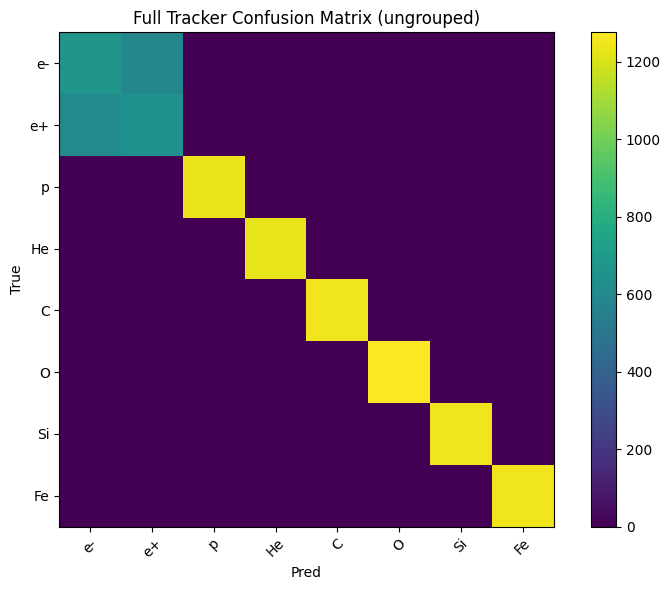

Saved figure to: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\figures\week2\week2_pid_confusion_matrix_ungrouped_integrated.png


In [25]:
labels = [s.label for s in SPECIES]
cm = confusion_matrix(y_test, pred, labels=labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest')
plt.title('Full Tracker Confusion Matrix (ungrouped)')
plt.colorbar()
ticks = np.arange(len(labels))
plt.xticks(ticks, labels, rotation=45)
plt.yticks(ticks, labels)
plt.ylabel('True')
plt.xlabel('Pred')
plt.tight_layout()

cm_path = FIG_DIR / "week2_pid_confusion_matrix_ungrouped_integrated.png"
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {cm_path.resolve()}")

Z_rich          0.271095
Z_trk           0.253311
Z_tof           0.251048
TRD_e_like      0.089254
shower_shape    0.066734
E_over_p        0.028861
R_tracker       0.016660
beta_rich       0.012685
beta_tof        0.010352
dtype: float64


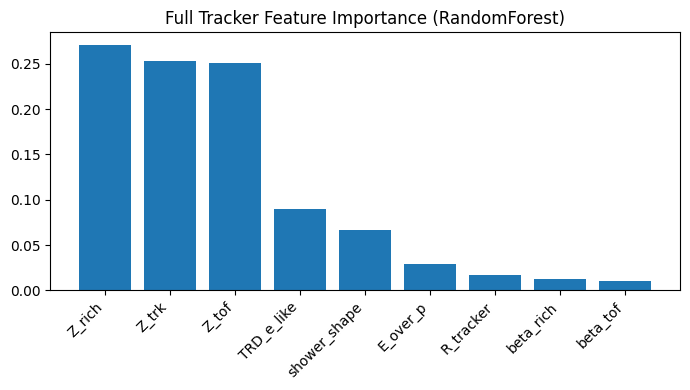

Saved figure to: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\figures\week2\week2_pid_feature_importance_integrated.png


In [32]:
imp = trainer.feature_importance()
print(imp)

plt.figure(figsize=(7, 4))
plt.bar(imp.index, imp.values)
plt.xticks(rotation=45, ha='right')
plt.title('Full Tracker Feature Importance (RandomForest)')
plt.tight_layout()

fi_path = FIG_DIR / "week2_pid_feature_importance_integrated.png"
plt.savefig(fi_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {fi_path.resolve()}")

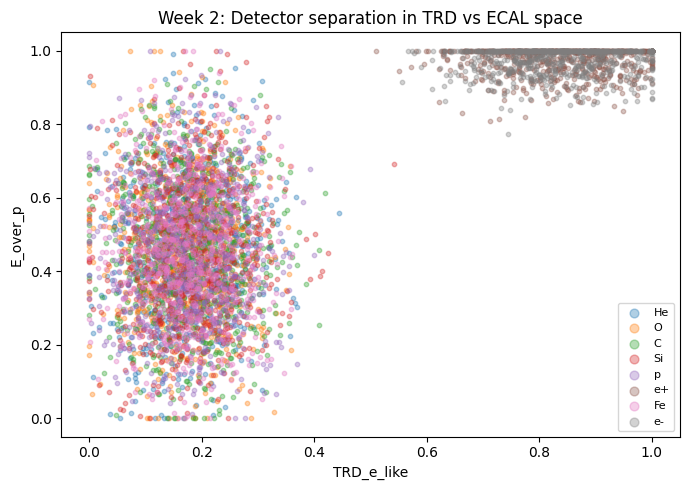

Saved figure to: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\figures\week2\week2_pid_trd_ecal_scatter_integrated.png


In [33]:
plt.figure(figsize=(7, 5))

sample_df = df.sample(min(len(df), 6000), random_state=42)

for label in sample_df["label"].unique():
    sub = sample_df[sample_df["label"] == label]
    plt.scatter(
        sub["TRD_e_like"],
        sub["E_over_p"],
        s=10,
        alpha=0.35,
        label=label
    )

plt.xlabel("TRD_e_like")
plt.ylabel("E_over_p")
plt.title("Week 2: Detector separation in TRD vs ECAL space")
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()

sep_path = FIG_DIR / "week2_pid_trd_ecal_scatter_integrated.png"
plt.savefig(sep_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {sep_path.resolve()}")

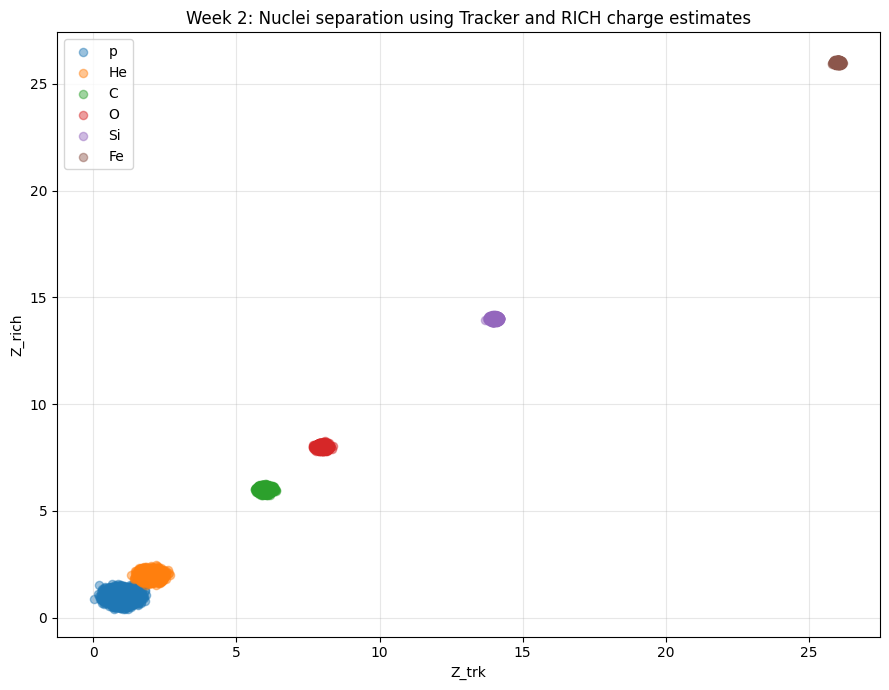

Saved figure to: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\figures\week2\week2_pid_nuclei_separation_integrated.png


In [43]:
# keep only nuclei (exclude electrons / positrons)
nuclei_labels = ["p", "He", "C", "O", "Si", "Fe"]
df_nuc = df[df["label"].isin(nuclei_labels)].copy()

# -----------------------------
# 1) Tracker vs RICH charge
# -----------------------------
plt.figure(figsize=(9, 7))

for label in nuclei_labels:
    sub = df_nuc[df_nuc["label"] == label]
    plt.scatter(
        sub["Z_trk"],
        sub["Z_rich"],
        s=35,
        alpha=0.45,
        label=label
    )

plt.xlabel("Z_trk")
plt.ylabel("Z_rich")
plt.title("Week 2: Nuclei separation using Tracker and RICH charge estimates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

nuc_path = FIG_DIR / "week2_pid_nuclei_separation_integrated.png"
plt.savefig(nuc_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {nuc_path.resolve()}")

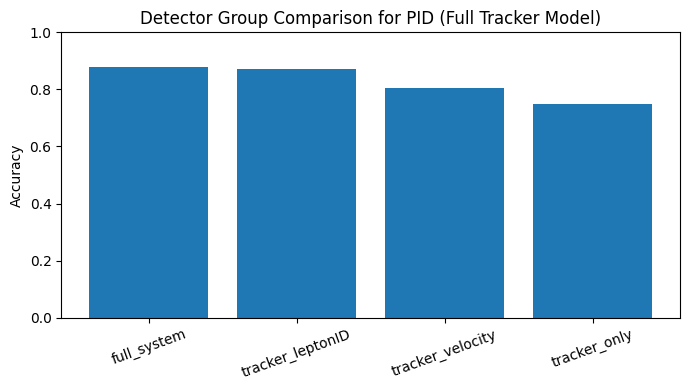

Saved figure to: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\figures\week2\week2_pid_grouped_comparison_integrated.png


In [44]:
plt.figure(figsize=(7,4))

plt.bar(results_df["model"], results_df["accuracy"])

plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("Detector Group Comparison for PID (Full Tracker Model)")

plt.xticks(rotation=20)

plt.tight_layout()
grouped_path = FIG_DIR / "week2_pid_grouped_comparison_integrated.png"
plt.savefig(grouped_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {grouped_path.resolve()}")

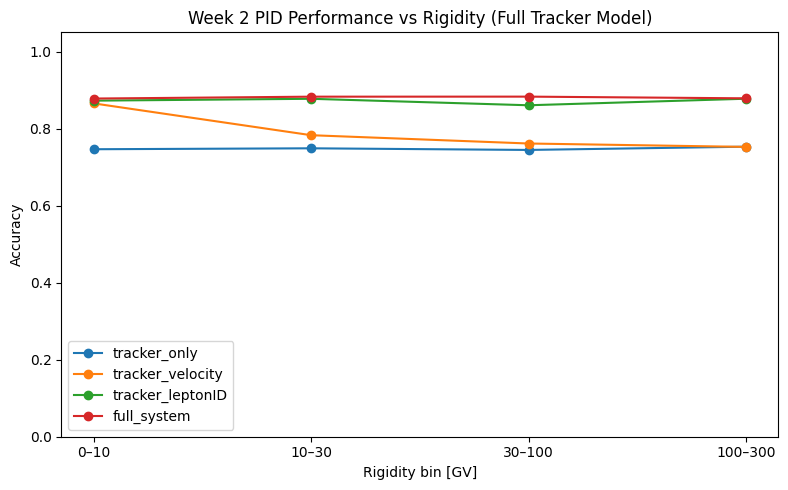

Saved: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\figures\week2\week2_pid_accuracy_vs_rigidity_integrated.png


In [45]:
plt.figure(figsize=(8,5))

for model_name in rigidity_results_df["model"].unique():
    sub = rigidity_results_df[rigidity_results_df["model"] == model_name]
    plt.plot(
        sub["rigidity_bin"],
        sub["accuracy"],
        marker="o",
        label=model_name
    )

plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.xlabel("Rigidity bin [GV]")
plt.title("Week 2 PID Performance vs Rigidity (Full Tracker Model)")
plt.legend()
plt.tight_layout()

rigidity_plot_path = FIG_DIR / "week2_pid_accuracy_vs_rigidity_integrated.png"
plt.savefig(rigidity_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", rigidity_plot_path)

In [46]:
rigidity_table_path = DATA_DIR / "week2_pid_accuracy_vs_rigidity_integrated.csv"
rigidity_results_df.to_csv(rigidity_table_path, index=False)

print("Saved:", rigidity_table_path)

Saved: C:\Users\ASUS\Desktop\AMS-02 Research\AMS-02-Research-Demo\data\week2_pid_accuracy_vs_rigidity_integrated.csv


### Confusion Matrix Comparison

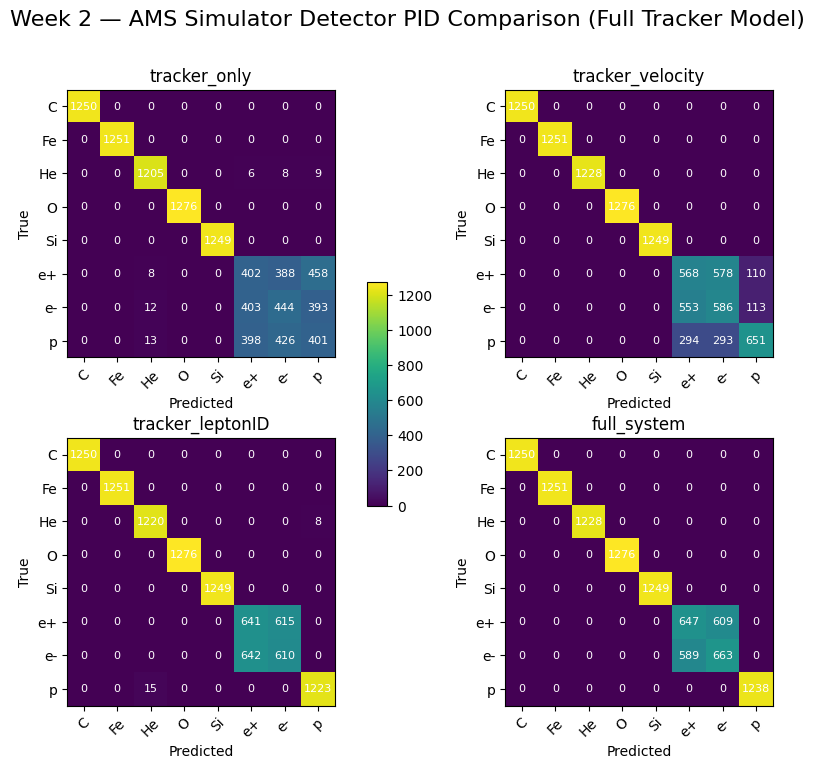

In [47]:
labels = sorted(df["label"].unique())

fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.flatten()

im = None

for ax, (model_name, info) in zip(axes, trained_models.items()):

    cm = confusion_matrix(info["y_test"], info["pred"], labels=labels)

    im = ax.imshow(cm)

    ax.set_title(model_name)

    ticks = np.arange(len(labels))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    ax.set_xticklabels(labels, rotation=45)
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # numbers in cells
    for (j,k), val in np.ndenumerate(cm):
        ax.text(k, j, int(val), ha='center', va='center', color='white', fontsize=8)

    ax.set_aspect('equal')

# tighten matrix spacing
plt.subplots_adjust(wspace=0.3, hspace=0.3)

# create a thin colorbar axis manually in the middle
cax = fig.add_axes([0.46, 0.36, 0.02, 0.28])
fig.colorbar(im, cax=cax)

fig.suptitle("Week 2 — AMS Simulator Detector PID Comparison (Full Tracker Model)", fontsize=16)

save_path = FIG_DIR / "week2_confusion_matrix_lattice_integrated.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

## Week 2 Interpretation

The simulated PID task shows the basic AMS-02 logic clearly:

- The **Tracker** provides rigidity and charge-related observables.
- **TOF** and **RICH** provide velocity measurements, with RICH being much more precise.
- The **TRD** strongly separates leptons from hadrons through an electron-likeness response.
- The **ECAL** separates electromagnetic and hadronic behavior through \(E/p\) and shower shape.

The classifier performs well not because of a single detector, but because AMS-style PID is redundant with more than one detector for obtaining deserved data.

In this simulator model, the strongest separation is expected from:
1. `TRD_e_like`
2. `E_over_p`
3. `shower_shape`
4. charge-related observables
5. precise velocity measurements

This completes Week 2 as a simplified multi-detector PID study.

## Full Tracker Model Interpretation

The integration of Week 1 Tracker Model slightly improves full_system accuracy as seen from the confusion matrices and rigidity vs accuracy table. The Tracker Model only measurement seems more accurate at higher energies but less accurate at lower energies. This could be due to increased effect of noise at lower energies.